# Zadanie 5: programowanie genetyczne i regresja symboliczna

Termin realizacji: 18 maja 2026

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Zmodyfikuj przykład `pysr_demo.ipynb` tak, aby uczył się funkcji $f(x) = 2.2\sin(x_0 + 2 x_1) - x_5^2 - 3$ której dziedziną jest $\mathbb{R}^6$. Uczenie ma się odbywać w oparciu o 200 wylosowanych z dziedziny próbek (między -5 a 5).
2. Zanotuj wzory trzech rozwiązań o najwyższej wartości `score` oraz rozwiązanie `best` dla następujących zestawów ustawień:
   1. `binary_operators=["+", "*"], unary_operators=["cos", "exp", "sin"], maxsize=20`,
   2. `binary_operators=["+", "*", "-", "^"], unary_operators=["cos", "exp", "sin", "log"], maxsize=30`, (dodaj ograniczenie dla argumentów operatora "^": [https://astroautomata.com/PySR/v1.5.9/options.html#constraining-use-of-operators](https://astroautomata.com/PySR/v1.5.9/options.html#constraining-use-of-operators).
   3. `binary_operators=["+", "*", "-", "^"], unary_operators=["exp", "sin"], maxsize=15`.
3. Powtórz eksperymenty z zadania na 3.0 po dodaniu szumu do próbek z funkcji $f$ (rozkład normalny o średniej 0 i odchyleniu standardowym 0.5)

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Dodaj do porównania dopasowanie oparte o próbki losowane w szerszym zakresie (między -15 a 15) oraz wyższy poziom szumu (odchylenie standardowe równe 2 oraz 5).

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Zamień funkcję $f$ na $f(x) = 2.2\sin(x_0 + 2x_1) - x_5^2 - p(\lfloor x_0 \rfloor)$ gdzie $p(i)$ oznacza $i$-tą liczbę pierwszą. Uwzględnij `p` jako dodatkowy operator unarny analogicznie do przykładu "Julia packages and types" z notatnika `pysr_demo.ipynb`. Powtórz eksperymenty opisane w zadaniach na 3.0 i 4.0.


In [2]:
import sympy
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Zadanie na 3.0

In [3]:
np.random.seed(0)
X = np.random.randn(200, 6) * 5
y = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - 3

In [4]:
binary_operators = [["+", "*"], ["+", "-", "*", "^"], ["+", "-", "*", "^"]]
unary_operators = [["cos", "exp", "sin"], ["cos", "exp", "sin", "log"], ["cos", "sin"]]
sizes = [20, 30, 15]
models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=100,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...


Model 1:


[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.810e+02  0.000e+00  y = -23.529
4           7.770e+02  1.668e-03  y = sin(x₁) + -23.568
5           8.702e+00  4.492e+00  y = (x₅ * -1.0571) * x₅
7           2.381e+00  6.481e-01  y = ((x₅ * -1.0037) * x₅) + -3.1152
9           2.380e+00  1.820e-04  y = (((x₅ + -0.0065274) * x₅) * -1.0038) + -3.1122
11          2.336e+00  9.323e-03  y = ((x₅ * (x₅ * -1.0037)) + -3.8945) + cos(cos(x₁))
12          2.289e+00  2.015e-02  y = ((x₅ * ((sin(x₂) * 0.012298) + -1.0062)) * x₅) + -3.09...
                                      06
13          2.229e+00  2.685e-02  y = sin(exp(x₅) * 0.22851) + (-3.3966 + ((x₅ * -0.99946) *...
                                       x₅))
14          7.083e-01  1.146e+00  y = ((x₅ * -1.002) * x₅) + (sin((x₀ + x₁) + x₁) + -3.0629)
16          4.910e-12  1.285e+01  y = ((sin(x₀ + (x₁ + x₁)) + -1.3636) * 2.2) + ((x₅ 

/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(


  - outputs/20260507_205741_b4VC2r/hall_of_fame.csv

Expressions evaluated per second: 3.750e+05
Progress: 2154 / 3100 total iterations (69.484%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.810e+02  0.000e+00  y = -23.531
4           7.766e+02  1.837e-03  y = -23.543 - sin(x₄)
5           2.391e+00  5.783e+00  y = -3.1903 - (x₅ * x₅)
7           2.381e+00  2.205e-03  y = ((x₅ * -1.0037) * x₅) + -3.1152
9           2.348e+00  6.908e-03  y = (-2.4116 - cos(sin(x₁))) - (x₅ * x₅)
10          2.329e+00  8.194e-03  y = (sin(x₂) * 0.35303) + (-3.2262 - (x₅ * x₅))
11          2.193e+00  6.024e-02  y = (-3.2988 - (x₅ * x₅)) + sin(exp(x₅) * 0.20058)
14          1.391e+00  1.517e-01  y = -3.1063 - ((x₅ * x₅) + cos(x₀ - (cos(cos(x₁)) * 8.3578...
                                      )))


[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


  - outputs/20260507_205755_xJimyF/hall_of_fame.csv
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.810e+02  0.000e+00  y = -23.531
4           7.766e+02  1.837e-03  y = -23.531 - sin(x₄)
5           2.391e+00  5.783e+00  y = -3.1902 - (x₅ * x₅)
7           2.381e+00  2.205e-03  y = -3.1152 - (x₅ * (x₅ * 1.0037))
9           2.347e+00  7.015e-03  y = -2.4229 - (cos(sin(x₁)) + (x₅ * x₅))
10          2.295e+00  2.245e-02  y = (sin(11.991 ^ x₁) + -3.2688) - (x₅ * x₅)
11          2.279e+00  6.984e-03  y = ((cos(x₄) * sin(x₄)) + -3.2072) - (x₅ * x₅)
12          7.108e-01  1.165e+00  y = sin(x₀ + (x₁ * 2.0044)) + (-3.1046 - (x₅ * x₅))
14          4.621e-12  1.288e+01  y = ((sin(x₀ + (x₁ + x₁)) * 2.2) + -3) - (x₅ * x₅)
───────────────────────────────────────────────────────────────────────────────────────────────────
  - outputs/20260507_205803_Ob6yN1/hall_of_fame.csv


In [5]:
for model in models:
    print(model.latex())

x_{5} x_{5} \left(-1.00\right) + \left(\sin{\left(x_{0} + x_{1} + x_{1} \right)} - 1.36\right) 2.20
- (x_{5} x_{5} + \cos{\left(- x_{0} + x_{1} \left(-2.00\right) + 1.57 \right)} \left(-2.20\right)) - 3.00
- x_{5} x_{5} + \sin{\left(x_{0} + x_{1} + x_{1} \right)} 2.20 - 3.00


## Zaszumione Dane

In [6]:
np.random.seed(0)

X = np.random.randn(200, 6) * 5

y_true = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - 3

noise_level = 0.5

noise = np.random.normal(0, noise_level, size=y_true.shape)

y = y_true + noise

Text(0, 0.5, '$y$')

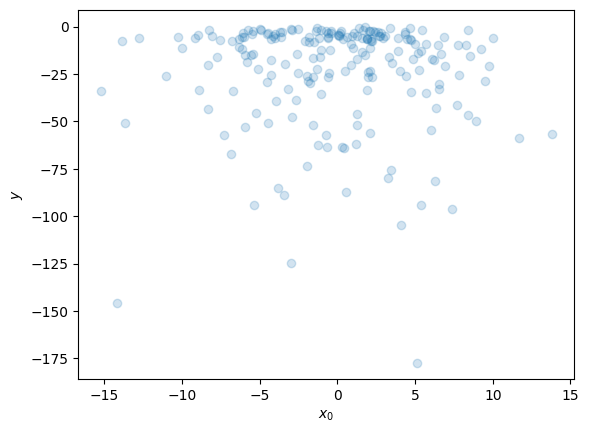

In [7]:
plt.scatter(X[:, 1], y, alpha=0.2)
plt.xlabel("$x_0$")
plt.ylabel("$y$")

In [8]:
binary_operators = [["+", "*"], ["+", "-", "*", "^"], ["+", "-", "*", "^"]]
unary_operators = [["cos", "exp", "sin"], ["cos", "exp", "sin", "log"], ["cos", "sin"]]
sizes = [20, 30, 15]
models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=100,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

Model 1:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(

───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.805e+02  0.000e+00  y = -23.53
4           7.767e+02  1.631e-03  y = sin(x₁) + -23.567
5           9.010e+00  4.457e+00  y = (x₅ * -1.0568) * x₅
7           2.653e+00  6.113e-01  y = ((x₅ * -1.0032) * x₅) + -3.1241
9           2.653e+00  9.538e-05  y = ((x₅ * -1.0033) * (x₅ + -0.0049755)) + -3.1217
11          2.609e+00  8.329e-03  y = cos(cos(x₅)) + ((x₅ * (x₅ * -1.0032)) + -3.8892)
12          2.585e+00  9.297e-03  y = (cos(x₅ * 0.29802) + (x₅ * (x₅ * -0.9831))) + -3.9348
13          2.570e+00  5.633e-03  y = ((x₅ * (x₅ * -1.0033)) + -3.8952) + cos(cos(x₄ + 0.753...
                                      2))
14          1.926e+00  2.885e-01  y = (cos(sin(cos(x₀) + x₁)) * -4.1126) + ((x₅ * -1.0005) *...
                                       x₅)
15          1.885e+00  2.171e-02  y = (cos(sin(sin(cos(x₀)) + x₁)) * -4.1456) + ((x₅ * 

[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.805e+02  0.000e+00  y = -23.53
4           7.762e+02  1.840e-03  y = -23.547 - sin(x₄)
5           2.661e+00  5.675e+00  y = -3.1898 - (x₅ * x₅)
7           2.653e+00  1.532e-03  y = -3.124 - (x₅ * (x₅ * 1.0032))
9           2.616e+00  7.086e-03  y = (-2.4246 - (x₅ * x₅)) - cos(sin(x₅))
10          2.575e+00  1.573e-02  y = (-2.546 - (x₅ * x₅)) - sin(exp(sin(x₁)))
11          2.512e+00  2.494e-02  y = sin(exp(x₅ * 0.38111)) - ((x₅ * x₅) - -3.5641)
13          1.992e+00  1.160e-01  y = (-3.1451 - (x₅ * x₅)) - cos(x₀ + cos(x₁ + x₁))
14          9.644e-01  7.252e-01  y = (-3.1037 - (x₅ * x₅)) - cos((x₀ + x₁) + (x₁ + 1.5466))
15          4.505e-01  7.612e-01  y = (exp(cos(((x₁ + x₀) + 1.5947) + x₁)) * -2.2162) - (x₅ ...
                                      * x₅)
16          2.335e-01  6.573e-01  y = (cos((x₁ + (x₀ + x₁)) + 1.5727) * -

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.805e+02  0.000e+00  y = -23.53
4           7.762e+02  1.840e-03  y = -23.541 - sin(x₄)
5           2.661e+00  5.675e+00  y = -3.1898 - (x₅ * x₅)
7           2.653e+00  1.532e-03  y = (x₅ * (x₅ * -1.0032)) + -3.1241
9           2.617e+00  6.959e-03  y = (-2.3988 - (x₅ * x₅)) - cos(sin(x₅))
10          2.494e+00  4.818e-02  y = (-3.5522 - (x₅ * x₅)) + sin(1.4788 ^ x₅)
11          2.486e+00  2.968e-03  y = (sin(sin(1.4788 ^ x₅)) - (x₅ * x₅)) + -3.5108
12          2.466e+00  8.028e-03  y = ((sin(1.4788 ^ x₅) - (x₅ * x₅)) + -3.6724) * 0.99464
14          2.392e+00  1.521e-02  y = (x₅ * (x₅ * -1.0029)) - (cos(sin(cos(x₀) + x₁)) + 2.34...
                                      82)
15          2.382e+00  4.257e-03  y = (x₅ * (x₅ * -1.0028)) - (cos(sin(x₁ + sin(cos(x₀)))) +...
                                       2.3525)
──────────────────

In [9]:
for model in models:
    print(model.latex())

x_{5} \left(-1.00\right) x_{5} + e^{\cos{\left(e^{\sin{\left(x_{0} + x_{1} + x_{1} \right)}} \right)}} \left(-1.91\right)
- x_{5} x_{5} + \cos{\left(x_{0} + x_{1} + x_{1} + 1.57 \right)} \left(-2.22\right) - 3.00
- x_{5} x_{5} - 3.19


## Zadanie na 4.0

In [10]:
np.random.seed(0)

X = np.random.randn(200, 6) * 15

y_true = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - 3

noise_level = 2
noise = np.random.normal(0, noise_level, size=y_true.shape)

y = y_true + noise

In [11]:
binary_operators = [["+", "*"], ["+", "-", "*", "^"], ["+", "-", "*", "^"]]
unary_operators = [["cos", "exp", "sin"], ["cos", "exp", "sin", "log"], ["cos", "sin"]]
sizes = [20, 30, 15]
models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=100,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

Model 1:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(

───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.261e+04  0.000e+00  y = -186.22
3           6.241e+04  -0.000e+00  y = x₃ + -186.17
5           1.367e+01  4.211e+00  y = (x₅ * -1.006) * x₅
7           7.101e+00  3.273e-01  y = (x₅ * (x₅ * -1)) + -3.1743
9           7.081e+00  1.452e-03  y = (((x₅ * -1) + 0.010645) * x₅) + -3.1601
11          6.986e+00  6.747e-03  y = (x₄ * 0.022797) + (((x₅ * -1) * x₅) + -3.1791)
12          6.649e+00  4.944e-02  y = (cos(x₃ * 0.29109) + -3.2097) + (x₅ * (x₅ * -1))
13          6.646e+00  3.994e-04  y = (-3.2034 + ((x₅ * -1) * x₅)) + sin(cos(x₃ * 0.28819))
14          6.575e+00  1.081e-02  y = (cos(x₃ + (x₅ * -0.36675)) + ((x₅ * -0.99994) * x₅)) +...
                                       -3.2843
16          6.297e+00  2.160e-02  y = ((x₅ * (x₅ * -1.0002)) + cos(((x₅ * -0.38721) + 0.7368...
                                      3) + x₃)) + -3.176

[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.261e+04  0.000e+00  y = -186.22
3           6.223e+04  1.062e-03  y = -187.41 - x₂
5           7.101e+00  4.537e+00  y = -3.175 - (x₅ * x₅)
7           7.081e+00  1.447e-03  y = (x₅ * (0.010487 - x₅)) - 3.1663
9           6.986e+00  6.691e-03  y = (-3.2114 - (x₅ * x₅)) - (x₄ * -0.022204)
10          6.649e+00  4.956e-02  y = (cos(x₃ * 0.29113) + -3.2114) - (x₅ * x₅)
12          6.555e+00  7.104e-03  y = (sin((1.3036 ^ x₅) + -0.40077) - 3.1668) - (x₅ * x₅)
15          6.041e+00  2.723e-02  y = ((3.0342 + (x₅ * x₅)) * -1.0002) + sin((sin(x₁) * -2.2...
                                      968) + x₀)
───────────────────────────────────────────────────────────────────────────────────────────────────
  - outputs/20260507_210112_O3xH1O/hall_of_fame.csv


In [12]:
for model in models:
    print(model.latex())

x_{5} x_{5} \left(-1.00\right) - 3.17
- x_{5} x_{5} + \sin{\left(x_{0} - x_{1} \left(-2.00\right) \right)} - 3.10
- x_{5} x_{5} - 3.17


## Wyniki dla poszczegołnych zestawów operatorów i funkcji

Orginalna funkcja: $f(x) = 2.2\sin(x_0 + 2 x_1) - x_5^2 - 3$

### Bez szumu (-5, 5)
$$ x_{5} x_{5} \left(-1.00\right) + \left(\sin{\left(x_{0} + x_{1} + x_{1} \right)} - 1.36\right) 2.20 $$
$$ - (x_{5} x_{5} + \cos{\left(- x_{0} + x_{1} \left(-2.00\right) + 1.57 \right)} \left(-2.20\right)) - 3.00 $$
$$ - x_{5} x_{5} + \sin{\left(x_{0} + x_{1} + x_{1} \right)} 2.20 - 3.00 $$

### Z szumem (-5, 5)

$$ x_{5} \left(-1.00\right) x_{5} + e^{\cos{\left(e^{\sin{\left(x_{0} + x_{1} + x_{1} \right)}} \right)}} \left(-1.91\right) $$
$$ - x_{5} x_{5} + \cos{\left(x_{0} + x_{1} + x_{1} + 1.57 \right)} \left(-2.22\right) - 3.00 $$
$$ - x_{5} x_{5} - 3.19 $$

### Z szumem (-15, 15)

$$ x_{5} x_{5} \left(-1.00\right) - 3.17 $$
$$ - x_{5} x_{5} + \sin{\left(x_{0} - x_{1} \left(-2.00\right) \right)} - 3.10 $$
$$ - x_{5} x_{5} - 3.17 $$

In [13]:
from pysr import jl

jl.seval(
    """
import Pkg
Pkg.add("Primes")
"""
)

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed IntegerMathUtils ─ v0.1.3
   Installed Primes ─────────── v0.5.7
    Updating `~/Desktop/Metody-i-algorytmy-optymalizacji/.env/julia_env/Project.toml`
  [27ebfcd6] + Primes v0.5.7
    Updating `~/Desktop/Metody-i-algorytmy-optymalizacji/.env/julia_env/Manifest.toml`
  [18e54dd8] + IntegerMathUtils v0.1.3
  [27ebfcd6] + Primes v0.5.7
Precompiling project...
    350.4 ms  ✓ IntegerMathUtils
    450.2 ms  ✓ Primes
  2 dependencies successfully precompiled in 2 seconds. 131 already precompiled.


In [14]:
jl.seval("using Primes: prime")

In [15]:
jl.seval(
    """
function p(i::T) where T
    if 0.5 < i < 1000
        return T(prime(round(Int, i)))
    else
        return T(NaN)
    end
end
"""
)

p (generic function with 1 method)

In [21]:
primes = {i: jl.p(i * 1.0) for i in range(1, 999)}

In [74]:
np.random.seed(0)
X = np.random.randn(200, 6) * 5
y = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - primes[np.floor(X[:, 0])[0]]

In [84]:
## Dodajemy operator p
binary_operators = [["+", "*"], ["+", "-", "*", "^"], ["+", "-", "*", "^"]]
unary_operators = [["cos", "exp", "sin", "p"], ["cos", "exp", "sin", "log", "p"], ["cos", "sin", "p"]]
sizes = [20, 30, 15]

models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=100,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

Model 1:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.526e+03  0.000e+00  y = -50.154
3           1.491e+03  1.128e-02  y = x₄ + -50.109
5           3.610e+02  7.092e-01  y = x₅ * (x₅ * -1.2826)
7           2.677e+00  2.452e+00  y = (x₅ * (x₅ * -1.0045)) + -23.049
9           2.675e+00  2.172e-04  y = (x₅ * ((x₅ * -1.0046) + -0.0065809)) + -23.047
11          2.643e+00  6.067e-03  y = (((x₅ * -1.0043) * x₅) + -23.161) + sin(exp(x₃))
12          2.557e+00  3.309e-02  y = sin(x₁ * -1.4475) + ((x₅ * (x₅ * -1.0034)) + -23.072)
13          2.524e+00  1.310e-02  y = ((x₅ * x₅) * -1.0035) + (sin(sin(x₁ * -1.4388)) + -23....
                                      061)
14          9.532e-01  9.737e-01  y = sin((x₁ + x₀) + x₁) + (((x₅ * -1.0018) * x₅) + -23.073...
                                      )
16          2.388e-01  6.922e-01  y = (sin(x₁ + (x₀ + x₁)) * 2.1807) + (((x₅ * x₅) * -0.9986.

[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.890e+05
Progress: 2158 / 3100 total iterations (69.613%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.526e+03  0.000e+00  y = -50.169
3           1.491e+03  1.128e-02  y = x₄ + -50.109
5           2.708e+00  3.156e+00  y = -23.171 - (x₅ * x₅)
7           2.677e+00  5.762e-03  y = -23.049 - (x₅ * (x₅ * 1.0045))
9           2.673e+00  6.313e-04  y = sin(exp(x₃)) - ((x₅ * x₅) + 23.223)
10          2.574e+00  3.768e-02  y = sin(x₁ * -1.4475) - ((x₅ * x₅) + 23.162)
11          2.543e+00  1.245e-02  y = (sin(sin(x₁ * -1.4324)) - (x₅ * x₅)) - 23.155
12          2.511e+00  1.261e-02  y = ((sin(x₁ * -1.4478) * 0.63739) - (x₅ * x₅)) - 23.166
14          2.449e+00  1.237e-02  y = (sin((-1.4475 * x₁) - sin(exp(x₂))) - (x₅ * x₅)) - 23....
              

[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.526e+03  0.000e+00  y = -50.153
3           1.491e+03  1.128e-02  y = x₄ + -50.109
5           2.708e+00  3.156e+00  y = -23.171 - (x₅ * x₅)
7           2.677e+00  5.762e-03  y = -23.049 - ((x₅ * 1.0045) * x₅)
9           2.673e+00  7.663e-04  y = -23.152 - (x₅ * (x₅ + (x₃ * -0.0069205)))
10          2.574e+00  3.747e-02  y = (-23.162 - (x₅ * x₅)) + sin(x₁ * -1.4429)
11          2.543e+00  1.239e-02  y = -23.155 - ((x₅ * x₅) + sin(sin(x₁ * 1.4324)))
12          9.583e-01  9.757e-01  y = (-23.122 - (x₅ * x₅)) + sin((x₁ + x₀) + x₁)
14          2.415e-01  6.892e-01  y = (sin(x₁ + (x₁ + x₀)) * 2.1698) + (-23.065 - (x₅ * x₅))
───────────────────────────────────────────────────────────────────────────────────────────────────
  - outputs/20260507_213040_h7Vk24/hall_of_fame.csv


In [85]:
for model in models:
    print(model.latex())

x_{5} x_{5} \left(-0.999\right) + \sin{\left(x_{0} + x_{1} + x_{1} \right)} 2.18 - 23.1
- x_{5} x_{5} + \sin{\left(x_{0} - x_{1} \left(-2.00\right) \right)} 2.17 - 23.1
- x_{5} x_{5} + \sin{\left(x_{0} + x_{1} + x_{1} \right)} 2.17 - 23.1


In [78]:
X = np.random.randn(200, 6) * 5
y_true = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - primes[np.floor(X[:, 0])[0]]

noise_level = 0.5
noise = np.random.normal(0, noise_level, size=y_true.shape)

y = y_true + noise

In [82]:
models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=100,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

Model 1:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 5.620e+05
Progress: 3066 / 3100 total iterations (98.903%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.526e+03  0.000e+00  y = -50.159
3           1.491e+03  1.128e-02  y = x₄ + -50.109
5           3.610e+02  7.092e-01  y = x₅ * (x₅ * -1.2826)
7           2.677e+00  2.452e+00  y = (x₅ * (x₅ * -1.0045)) + -23.049
9           2.675e+00  2.172e-04  y = (((x₅ * -1.0046) + -0.0065811) * x₅) + -23.047
11          2.643e+00  6.067e-03  y = (x₅ * (x₅ * -1.0043)) + (sin(exp(x₃)) + -23.161)
12          2.557e+00  3.309e-02  y = (((x₅ * -1.0034) * x₅) + -23.072) + sin(x₁ * -1.4475)
13          2.524e+00  1.310e-02  y = (x₅ * (x₅ * -1.0035)) + (sin(sin(x₁ * -1.4388)) + -23....
                                      061)
14          9.532e-01  9.737e-01  

[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 4.090e+05
Progress: 2166 / 3100 total iterations (69.871%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.526e+03  0.000e+00  y = -50.159
3           1.491e+03  1.128e-02  y = x₄ + -50.109
5           2.708e+00  3.156e+00  y = -23.171 - (x₅ * x₅)
7           2.677e+00  5.762e-03  y = (x₅ * (x₅ * -1.0045)) + -23.049
9           2.675e+00  2.172e-04  y = ((x₅ * (x₅ + 0.0065389)) * -1.0046) + -23.047
10          2.575e+00  3.826e-02  y = sin(x₁ * -1.4324) + (-23.155 - (x₅ * x₅))
11          2.543e+00  1.270e-02  y = sin(sin(x₁ * -1.4324)) + (-23.155 - (x₅ * x₅))
12          2.527e+00  5.998e-03  y = (-23.15 - (x₅ * x₅)) + sin(sin(sin(x₁ * -1.4232)))
13          2.519e+00  3.195e-03  y = sin(sin(sin(sin(x₁ * -1.4232)))) + (-23.15 - (x₅ * x₅)...
   

[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.526e+03  0.000e+00  y = -50.159
3           1.491e+03  1.128e-02  y = x₄ + -50.109
5           2.708e+00  3.156e+00  y = -23.171 - (x₅ * x₅)
7           2.677e+00  5.762e-03  y = (x₅ * (x₅ * -1.0045)) + -23.049
9           2.675e+00  2.172e-04  y = ((x₅ * (x₅ + 0.0065389)) * -1.0046) + -23.047
10          2.574e+00  3.857e-02  y = (sin(x₁ * -1.443) - (x₅ * x₅)) + -23.162
11          2.543e+00  1.239e-02  y = sin(sin(x₁ * -1.4323)) + (-23.155 - (x₅ * x₅))
12          9.583e-01  9.757e-01  y = (sin(x₁ + (x₀ + x₁)) - (x₅ * x₅)) + -23.122
13          8.715e-01  9.494e-02  y = (exp(sin((x₁ + x₀) + x₁)) - (x₅ * x₅)) + -24.392
15          3.570e-01  4.462e-01  y = (exp(sin((x₁ + x₀) + x₁) + 0.63079) - (x₅ * x₅)) + -25...
                                      .466
16          2.388e-01  4.024e-01  y = ((x₅ * (x₅ * -0.99865)) - (sin(x₁ + (x

[ Info: Final population:
[ Info: Results saved to:


  - outputs/20260507_212918_8EmsgJ/hall_of_fame.csv


In [83]:
for model in models:
    print(model.latex())

x_{5} x_{5} \left(-0.999\right) + \sin{\left(x_{0} + x_{1} \cdot 2.00 \right)} 2.18 - 23.1
x_{5} x_{5} \left(-0.999\right) - \sin{\left(x_{0} + x_{1} + x_{1} \right)} \left(-2.18\right) - 23.1
- x_{5} x_{5} - 23.2


In [86]:
X = np.random.randn(200, 6) * 5
y_true = 2.2 * np.sin(X[:, 0] + 2 * X[:, 1]) - X[:, 5] ** 2 - primes[np.floor(X[:, 0])[0]]

noise_level = 2
noise = np.random.normal(0, noise_level, size=y_true.shape)

y = y_true + noise

In [87]:
models = []

for i in range(3):
    print(f"Model {i+1}:")
    model = PySRRegressor(
        niterations=100,
        binary_operators=binary_operators[i],
        unary_operators=unary_operators[i],
        maxsize=sizes[i],
    )

    model.fit(X, y)
    models.append(model)

Model 1:


/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.181e+03  0.000e+00  y = -35.817
3           1.167e+03  5.948e-03  y = x₀ + -36.077
5           1.288e+02  1.102e+00  y = (x₅ * x₅) * -1.1722
7           5.647e+00  1.564e+00  y = (x₅ * (x₅ * -0.99525)) + -13.283
9           5.563e+00  7.522e-03  y = (x₅ * ((x₅ * -0.99576) + 0.061187)) + -13.283
10          5.260e+00  5.589e-02  y = (((x₅ * -0.99479) * x₅) + -13.235) + cos(x₂)
11          5.251e+00  1.819e-03  y = (x₅ * (x₅ * -0.99491)) + (sin(cos(x₂)) + -13.238)
12          5.163e+00  1.684e-02  y = ((x₅ * (x₅ * -0.99478)) + -13.246) + cos(x₂ + 0.45316)
13          5.154e+00  1.856e-03  y = ((x₅ * (x₅ * -0.99485)) + sin(cos(x₂ + 0.45916))) + -1...
                                      3.25
14          5.126e+00  5.304e-03  y = cos(x₂ + 0.44294) + ((x₅ * ((x₅ * -0.99511) + 0.04047)...
                                      ) + -13.24

[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.710e+05
Progress: 1996 / 3100 total iterations (64.387%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.181e+03  0.000e+00  y = -35.82
3           1.159e+03  9.489e-03  y = -35.942 - x₁
5           5.674e+00  2.660e+00  y = -13.175 - (x₅ * x₅)
7           5.584e+00  7.973e-03  y = ((0.063007 - x₅) * x₅) - 13.188
8           5.293e+00  5.361e-02  y = (cos(x₂) + -13.117) - (x₅ * x₅)
9           5.282e+00  2.078e-03  y = (sin(cos(x₂)) - (x₅ * x₅)) + -13.122
10          5.196e+00  1.644e-02  y = (cos(x₂ + 0.45381) - (x₅ * x₅)) + -13.128
11          5.185e+00  2.008e-03  y = (sin(cos(x₂ + 0.45776)) - (x₅ * x₅)) + -13.133
12          5.155e+00  5.899e-03  y = (cos(-0.44321 - x₂) - (x₅ * (x₅ + -0.042584))) + -13.1...
                                

[ Info: Final population:
[ Info: Results saved to:
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/janrolka/Desktop/Metody-i-algorytmy-optymalizacji/.env/lib/python3.12/site-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.181e+03  0.000e+00  y = -35.818
3           1.159e+03  9.489e-03  y = -35.942 - x₁
5           5.674e+00  2.660e+00  y = -13.175 - (x₅ * x₅)
7           5.584e+00  7.973e-03  y = -13.188 - ((x₅ + -0.063016) * x₅)
8           5.293e+00  5.361e-02  y = cos(x₂) + (-13.117 - (x₅ * x₅))
9           5.282e+00  2.078e-03  y = (sin(cos(x₂)) - 13.122) - (x₅ * x₅)
10          5.196e+00  1.644e-02  y = cos(-0.45417 - x₂) + (-13.128 - (x₅ * x₅))
11          5.185e+00  2.008e-03  y = (sin(cos(x₂ + 0.45798)) - 13.133) - (x₅ * x₅)
12          5.155e+00  5.898e-03  y = cos(x₂ - -0.44325) + (((0.042573 - x₅) * x₅) - 13.136)
13          5.115e+00  7.686e-03  y = (cos(sin(x₀ - x₄) - x₂) - 13.115) - (x₅ * x₅)
14          5.113e+00  5.075e-04  y = (cos(sin(sin(x₀ - x₄)) - x₂) - 13.125) - (x₅ * x₅)
15          5.001e+00  2.211e-02  y = (cos((sin(x₄ + x₀

In [88]:
for model in models:
    print(model.latex())

x_{5} \left(-0.996\right) x_{5} + \cos{\left(x_{0} + x_{1} + x_{1} - 1.54 \right)} - 13.2
- (x_{5} x_{5} - \sin{\left(x_{0} + x_{1} + x_{1} \right)}) - 13.1
- x_{5} x_{5} - 13.2


## Wyniki dla poszczegołnych zestawów operatorów i funkcji

Orginalna funkcja: $f(x) = 2.2\sin(x_0 + 2 x_1) - x_5^2 - p(\lfloor x_0 \rfloor)$

### Bez szumu (-5, 5)
$$ \left(x_{5} x_{5} + 23.3\right) \left(-1.00\right) + \cos{\left(\cos{\left(x_{1} + \cos{\left(x_{0} \right)} \right)} \right)} 5.55 $$
$$ - x_{5} x_{5} + \sin{\left(x_{0} + x_{1} + x_{1} \right)} 2.20 - 19.0 $$
$$ - x_{5} x_{5} + \sin{\left(x_{0} + x_{1} + x_{1} \right)} - 19.1 $$

### Z szumem (-5, 5)

$$ x_{5} x_{5} \left(-0.999\right) + \sin{\left(x_{0} + x_{1} \cdot 2.00 \right)} 2.18 - 23.1 $$
$$ x_{5} x_{5} \left(-0.999\right) - \sin{\left(x_{0} + x_{1} + x_{1} \right)} \left(-2.18\right) - 23.1 $$
$$ - x_{5} x_{5} - 23.2 $$

### Z szumem (-15, 15)

$$ x_{5} \left(-0.996\right) x_{5} + \cos{\left(x_{0} + x_{1} + x_{1} - 1.54 \right)} - 13.2 $$
$$ - (x_{5} x_{5} - \sin{\left(x_{0} + x_{1} + x_{1} \right)}) - 13.1 $$
$$ - x_{5} x_{5} - 13.2 $$